#### Train image

Keys in the file: ['ismrmrd_header', 'kspace', 'reconstruction_rss', 'target']


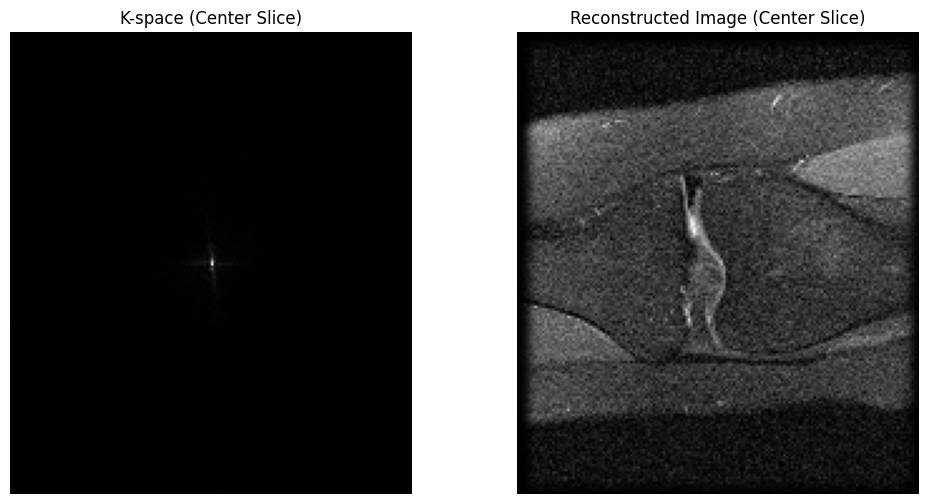

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import ifft2, fftshift, ifftshift

# Load the HDF5 file
file_path = "/Users/zoeazra/Documents/CLS/Y1/DL4MI/AI4MedicalImaging/Assignment3/file147.h5"

with h5py.File(file_path, 'r') as f:
    print("Keys in the file:", list(f.keys()))  # Check available keys
    kspace_data = f['kspace'][:]  # Load k-space data

# Ensure k-space data is at least 3D (num_slices, height, width)
if len(kspace_data.shape) == 4:  # (num_slices, coils, height, width)
    kspace_data = kspace_data[:, 0, :, :]  # Take first coil if multiple coils exist

# Select the center slice
center_slice_idx = kspace_data.shape[0] // 2
kspace_slice = kspace_data[center_slice_idx]  # Extract center slice

# Ensure the slice is 2D
kspace_slice = np.squeeze(kspace_slice)  # Remove singleton dimensions if necessary

# Apply Inverse Fourier Transform to reconstruct the image
image_data = fftshift(ifft2(ifftshift(kspace_slice)))  # Inverse FFT
image_magnitude = np.abs(image_data)  # Take magnitude

# Log scale for better k-space visualization
kspace_magnitude = np.log1p(np.abs(kspace_slice))

# Plot K-space and Image space representations
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# K-space plot
axes[0].imshow(kspace_magnitude, cmap='gray')
axes[0].set_title("K-space (Center Slice)")
axes[0].axis("off")

# Image-space plot
axes[1].imshow(image_magnitude, cmap='gray')
axes[1].set_title("Reconstructed Image (Center Slice)")
axes[1].axis("off")

plt.show()


Keys in the file: ['ismrmrd_header', 'kspace', 'reconstruction_rss', 'target']


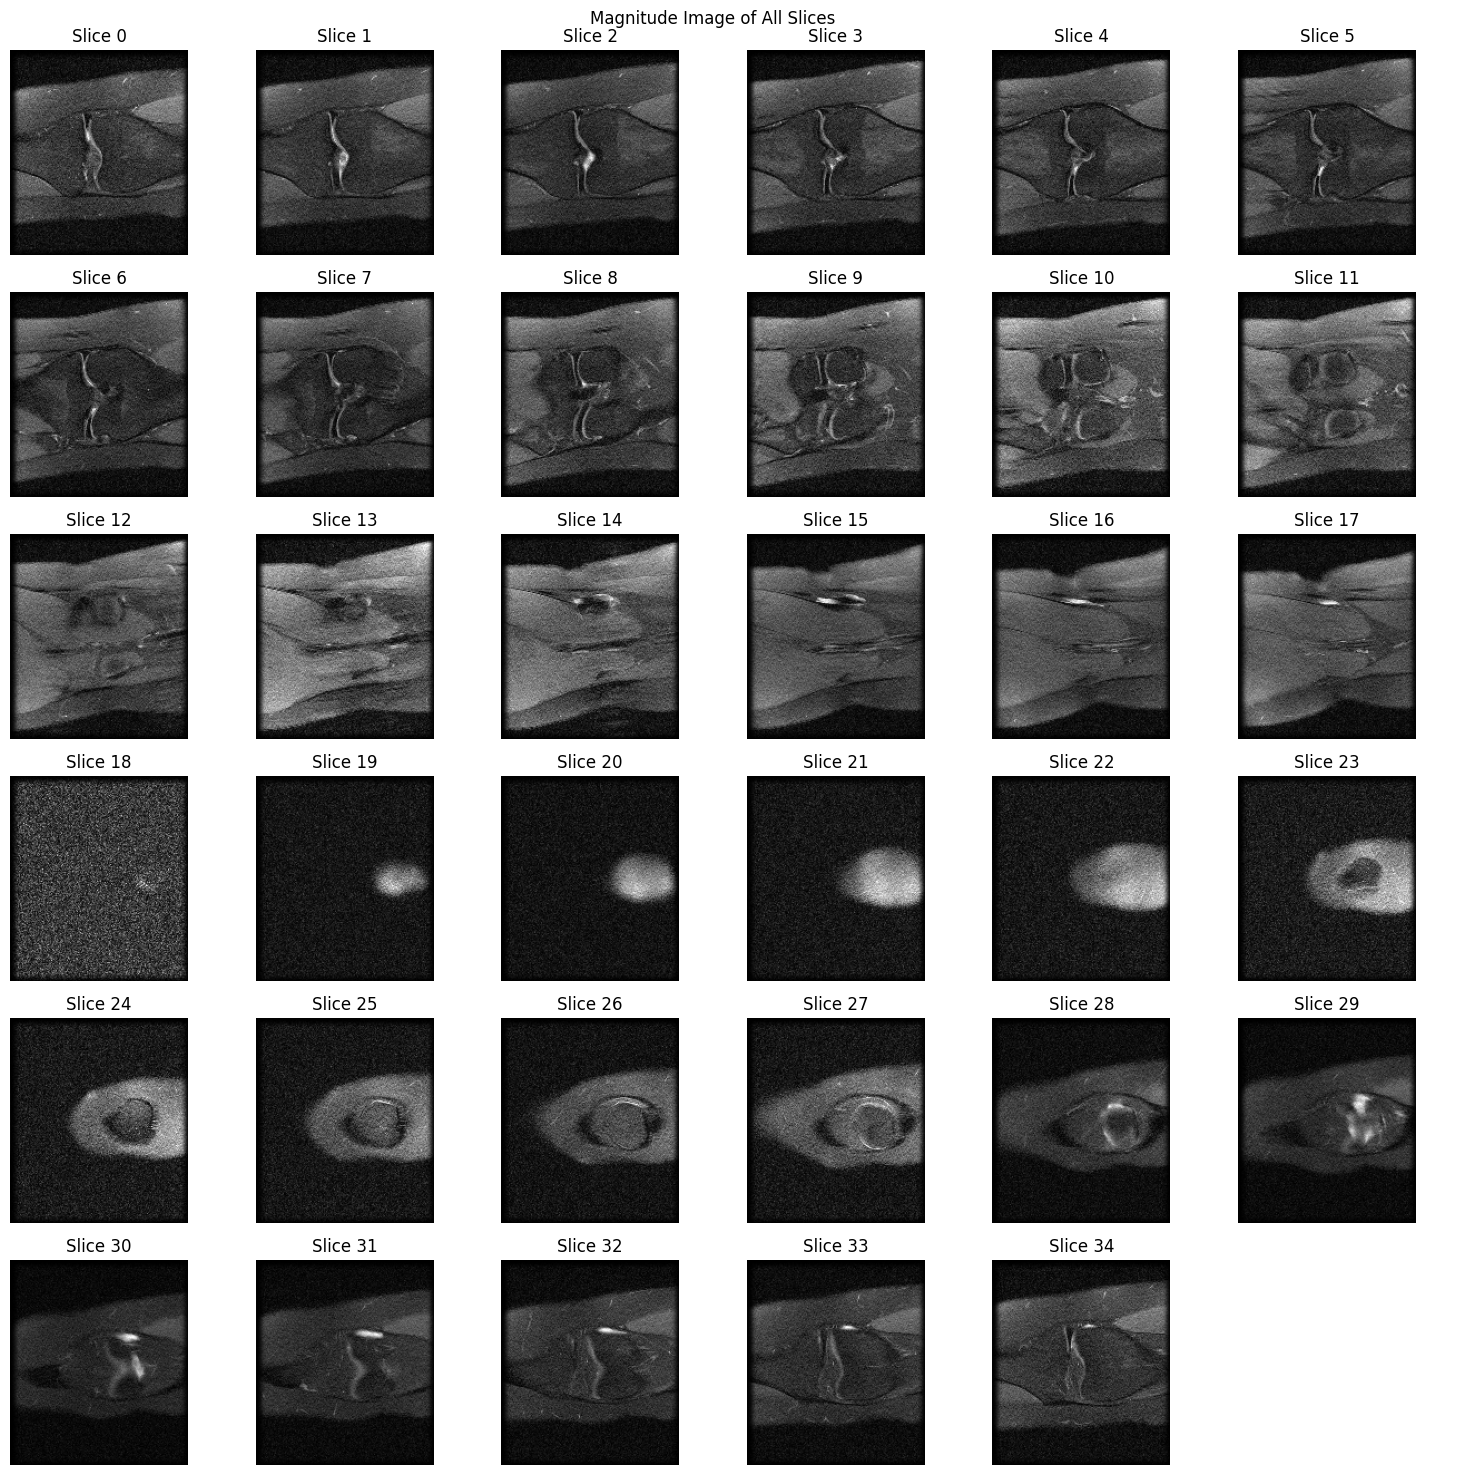

In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import ifft2, fftshift, ifftshift

# Load the HDF5 file
file_path = "/Users/zoeazra/Documents/CLS/Y1/DL4MI/AI4MedicalImaging/Assignment3/file147.h5"

with h5py.File(file_path, 'r') as f:
    print("Keys in the file:", list(f.keys()))  # Check available keys
    kspace_data = f['kspace'][:]  # Load k-space data

# Handle multi-coil data (if applicable)
if len(kspace_data.shape) == 4:  # (num_slices, coils, height, width)
    kspace_data = kspace_data[:, 0, :, :]  # Take first coil if multiple exist

# Apply Inverse Fourier Transform to reconstruct all slices
image_data = fftshift(ifft2(ifftshift(kspace_data)), axes=(-2, -1))  # Apply IFFT
image_magnitude = np.abs(image_data)  # Take magnitude

# Determine grid size for tiled display
num_slices = image_magnitude.shape[0]
cols = int(np.ceil(np.sqrt(num_slices)))  # Square root for balanced grid
rows = int(np.ceil(num_slices / cols))

# Plot all slices in a tiled display
fig, axes = plt.subplots(rows, cols, figsize=(15, 15))

for i in range(rows * cols):
    ax = axes[i // cols, i % cols]
    if i < num_slices:
        ax.imshow(image_magnitude[i], cmap='gray')
        ax.set_title(f"Slice {i}")
        ax.axis("off")
    else:
        ax.axis("off")  # Hide empty subplots

plt.suptitle("Magnitude Image of All Slices")
plt.tight_layout()
plt.show()


Keys in the file: ['ismrmrd_header', 'kspace', 'reconstruction_rss', 'target']


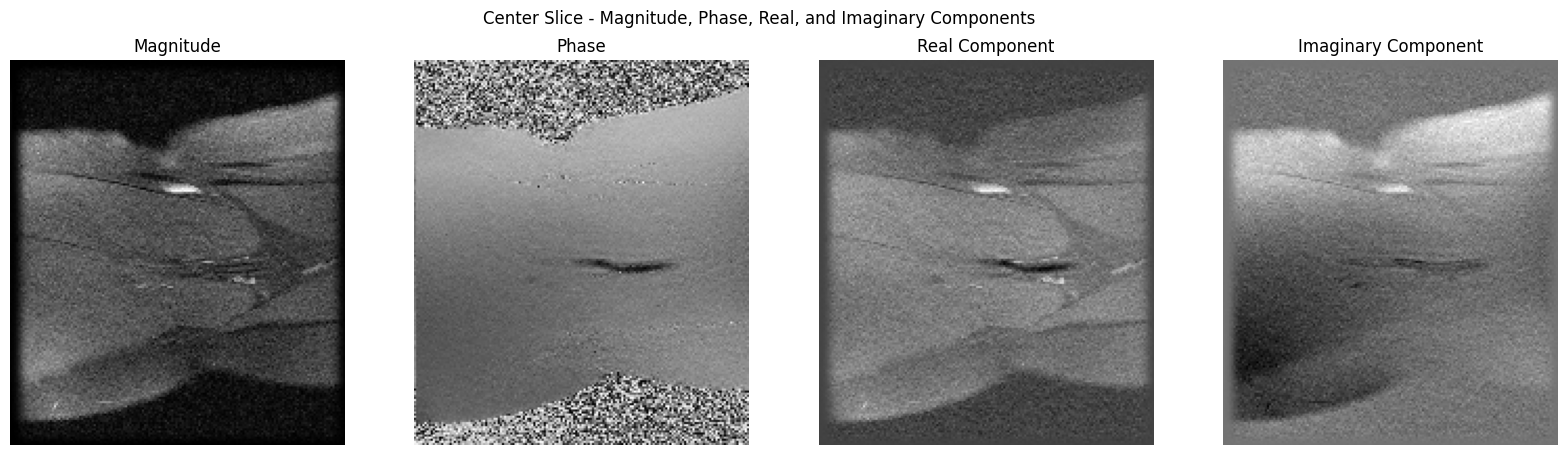

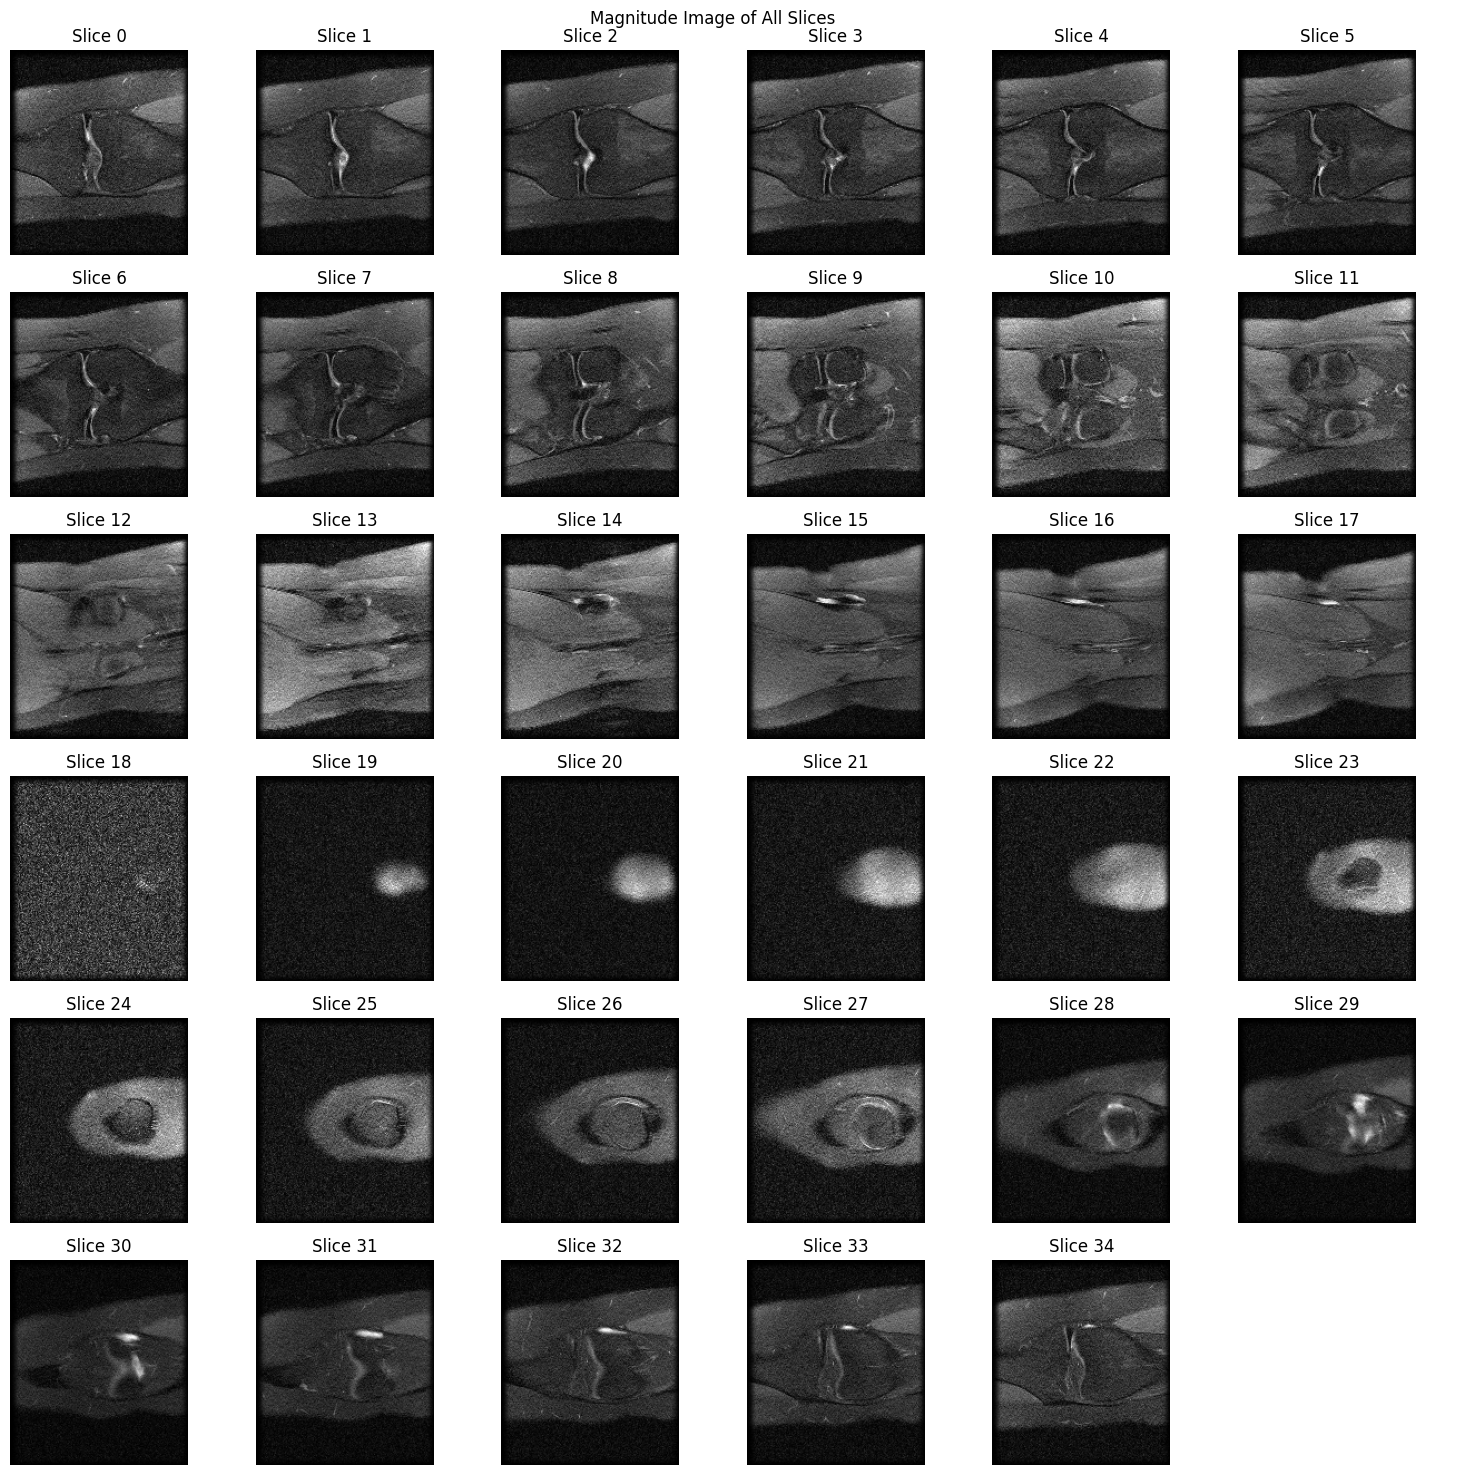

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import ifft2, fftshift, ifftshift

# Load the HDF5 file
file_path = "/Users/zoeazra/Documents/CLS/Y1/DL4MI/AI4MedicalImaging/Assignment3/file147.h5"

with h5py.File(file_path, 'r') as f:
    print("Keys in the file:", list(f.keys()))  # Check available keys
    kspace_data = f['kspace'][:]  # Load k-space data

# Handle multi-coil data (if applicable)
if len(kspace_data.shape) == 4:  # (num_slices, coils, height, width)
    kspace_data = kspace_data[:, 0, :, :]  # Take first coil if multiple exist

# Apply Inverse Fourier Transform to reconstruct all slices
image_data = fftshift(ifft2(ifftshift(kspace_data)), axes=(-2, -1))  # Apply IFFT

# Extract magnitude, phase, real, and imaginary components
image_magnitude = np.abs(image_data)
image_phase = np.angle(image_data)
image_real = np.real(image_data)
image_imaginary = np.imag(image_data)

# Select center slice
center_slice_idx = image_data.shape[0] // 2
magnitude_slice = image_magnitude[center_slice_idx]
phase_slice = image_phase[center_slice_idx]
real_slice = image_real[center_slice_idx]
imaginary_slice = image_imaginary[center_slice_idx]

# Plot the four components
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(magnitude_slice, cmap='gray')
axes[0].set_title("Magnitude")
axes[0].axis("off")

axes[1].imshow(phase_slice, cmap='gray')
axes[1].set_title("Phase")
axes[1].axis("off")

axes[2].imshow(real_slice, cmap='gray')
axes[2].set_title("Real Component")
axes[2].axis("off")

axes[3].imshow(imaginary_slice, cmap='gray')
axes[3].set_title("Imaginary Component")
axes[3].axis("off")

plt.suptitle("Center Slice - Magnitude, Phase, Real, and Imaginary Components")
plt.show()

# ---- Plot All Slices in a Tiled Display ----
num_slices = image_magnitude.shape[0]
cols = int(np.ceil(np.sqrt(num_slices)))  # Square root for balanced grid
rows = int(np.ceil(num_slices / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 15))

for i in range(rows * cols):
    ax = axes[i // cols, i % cols]
    if i < num_slices:
        ax.imshow(image_magnitude[i], cmap='gray')
        ax.set_title(f"Slice {i}")
        ax.axis("off")
    else:
        ax.axis("off")  # Hide empty subplots

plt.suptitle("Magnitude Image of All Slices")
plt.tight_layout()
plt.show()


The range of values of the phase is between -pi and pi

#### Test image